<a href="https://colab.research.google.com/github/deltorobarba/astrophysics/blob/main/emission_nebula_h1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Structure of H-I nebula emissions**

Emission Nebula) of type H-I region, also known as H-I region or neutral hydrogen region, refers to areas in space where neutral hydrogen (H-I) is found. While these regions aren't ionized like H-II regions (where hydrogen is ionized and emits light), studying them often involves radio astronomy to detect the 21 cm line emitted by neutral hydrogen.

Here’s a Python example using a mock dataset to analyze H-I regions with astronomical libraries like Astropy and Matplotlib. This example will simulate radio data for neutral hydrogen at 21 cm and perform basic analysis:



In [1]:
!pip install astropy matplotlib -q

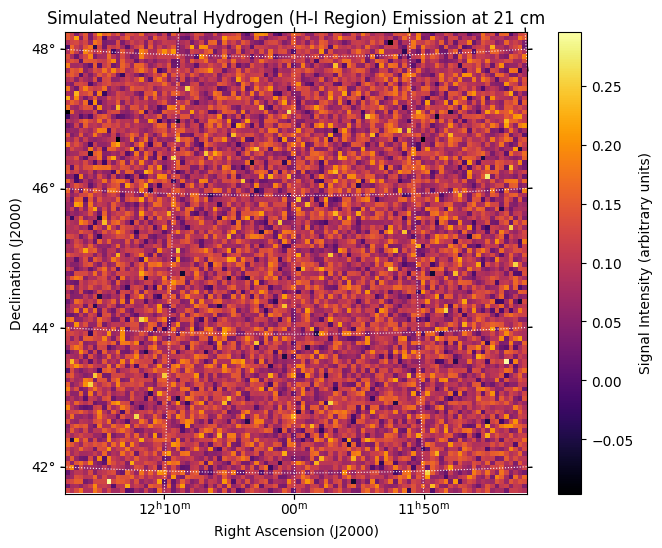

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.visualization import simple_norm
from astropy.wcs import WCS

# Simulate some mock radio data for H-I region (21 cm line)
# Normally, you would load real data from a fits file
np.random.seed(42)
data = np.random.normal(loc=0.1, scale=0.05, size=(100, 100))  # Simulated data for H-I region

# Create a simple WCS object for the plot
wcs = WCS(naxis=2)
wcs.wcs.crpix = [50, 50]
wcs.wcs.cdelt = np.array([-0.066667, 0.066667])
wcs.wcs.crval = [180, 45]
wcs.wcs.ctype = ["RA---TAN", "DEC--TAN"]

# Plot the data
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection=wcs)
norm = simple_norm(data, 'linear', percent=99)

ax.imshow(data, norm=norm, origin='lower', cmap='inferno')
ax.set_title("Simulated Neutral Hydrogen (H-I Region) Emission at 21 cm")
ax.set_xlabel("Right Ascension (J2000)")
ax.set_ylabel("Declination (J2000)")

plt.colorbar(ax.imshow(data, cmap='inferno', origin='lower'), ax=ax, label='Signal Intensity (arbitrary units)')
plt.grid(color='white', ls='dotted')
plt.show()

The inferno colormap highlights the structure of the H-I emissions.

Data Simulation: The mock data is created using a normal distribution to simulate H-I signal variations. In real cases, you would use FITS (Flexible Image Transport System) files containing observations of 21 cm radio emissions.

Astropy: This library is used for managing World Coordinate System (WCS) information, which relates pixel coordinates to right ascension (RA) and declination (DEC) on the sky.

(To perform more detailed analysis (such as calculating the column density of neutral hydrogen), you would need to integrate over the 21 cm spectral line and use physical constants relevant to H-I regions.)

In [12]:
#!pip install spectral_cube -q
from astropy.io import fits
from spectral_cube import SpectralCube
import numpy as np
import matplotlib.pyplot as plt
from astropy import units as u

import pandas as pd

# Replace with your actual GitHub raw file URL
fits.fits = 'https://raw.githubusercontent.com/deltorobarba/astrophysics/fits.fits'


# Load the FITS file (replace 'your_fits_file.fits' with your actual file)
cube = SpectralCube.read('fits.fits')

# Convert the cube to brightness temperature if necessary
# Some FITS files are already in brightness temperature, check the units
cube = cube.with_spectral_unit(u.km / u.s, velocity_convention='radio')

# Define the velocity range (in km/s) for the H-I line integration
velocity_range = [0 * u.km / u.s, 100 * u.km / u.s]  # Adjust this range to your data

# Slice the cube over the defined velocity range
hi_cube = cube.spectral_slab(velocity_range[0], velocity_range[1])

# Sum over the velocity axis to integrate the spectral line
integrated_intensity = hi_cube.moment(order=0)  # Moment 0 is the integral of intensity over velocity

# Calculate the column density of neutral hydrogen
# Using the factor 1.823e18 to convert to cm^-2
N_HI = integrated_intensity.value * 1.823e18  # Column density in cm^-2

# Plot the column density map
plt.figure(figsize=(8, 6))
plt.imshow(N_HI, origin='lower', cmap='inferno')
plt.colorbar(label=r'N$_{HI}$ (cm$^{-2}$)')
plt.title('Neutral Hydrogen Column Density (H-I Region)')
plt.xlabel('RA (J2000)')
plt.ylabel('DEC (J2000)')
plt.grid(color='white', ls='dotted')
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: 'fits'

Yes, it's absolutely possible to work with real FITS files containing observations of the 21 cm radio emissions and to integrate over the 21 cm spectral line to calculate the column density of neutral hydrogen in H-I regions.

Here’s a step-by-step guide for how to do this:

1. **Load the FITS File:**
You would need a FITS file containing radio observations of neutral hydrogen (H-I) at the 21 cm spectral line. FITS files are often 3D data cubes, where two dimensions are spatial (RA and DEC) and the third dimension corresponds to the frequency or velocity axis.

2. **Extract the Spectral Line and Data Cube:**
The 21 cm line corresponds to a specific frequency (~1420.4 MHz), and for different parts of the sky, the observed frequency may be shifted due to Doppler effects (moving gas). You’ll need to integrate over the frequency axis to capture the entire emission of neutral hydrogen.

3. **Calculate Column Density:**
The column density of neutral hydrogen \( N_{\text{HI}} \) can be calculated using the following equation:

\[
N_{\text{HI}} = 1.823 \times 10^{18} \, \text{cm}^{-2} \, \int T_b(v) \, dv
\]

Where:
- \( T_b(v) \) is the brightness temperature in Kelvin,
- \( v \) is the velocity in km/s, and
- The integral is performed over the velocity range of the H-I line.

Python Code Example using **Astropy** and **SpectralCube** libraries:

```python
from astropy.io import fits
from spectral_cube import SpectralCube
import numpy as np
import matplotlib.pyplot as plt
from astropy import units as u

# Load the FITS file (replace 'your_fits_file.fits' with your actual file)
cube = SpectralCube.read('your_fits_file.fits')

# Convert the cube to brightness temperature if necessary
# Some FITS files are already in brightness temperature, check the units
cube = cube.with_spectral_unit(u.km / u.s, velocity_convention='radio')

# Define the velocity range (in km/s) for the H-I line integration
velocity_range = [0 * u.km / u.s, 100 * u.km / u.s]  # Adjust this range to your data

# Slice the cube over the defined velocity range
hi_cube = cube.spectral_slab(velocity_range[0], velocity_range[1])

# Sum over the velocity axis to integrate the spectral line
integrated_intensity = hi_cube.moment(order=0)  # Moment 0 is the integral of intensity over velocity

# Calculate the column density of neutral hydrogen
# Using the factor 1.823e18 to convert to cm^-2
N_HI = integrated_intensity.value * 1.823e18  # Column density in cm^-2

# Plot the column density map
plt.figure(figsize=(8, 6))
plt.imshow(N_HI, origin='lower', cmap='inferno')
plt.colorbar(label=r'N$_{HI}$ (cm$^{-2}$)')
plt.title('Neutral Hydrogen Column Density (H-I Region)')
plt.xlabel('RA (J2000)')
plt.ylabel('DEC (J2000)')
plt.grid(color='white', ls='dotted')
plt.show()
```

Key Steps:

1. **Load the FITS file**: `SpectralCube.read` loads the FITS file into a data cube, where two dimensions are spatial (RA and DEC), and one dimension is spectral (velocity or frequency).
   
2. **Convert to Velocity Units**: The spectral axis is converted to velocity using the `with_spectral_unit` function, which is important since the 21 cm line may be Doppler shifted depending on the velocity of the gas.

3. **Select Velocity Range**: You define a velocity range over which the H-I emission is present. This range can vary depending on the data and the velocity of the observed gas.

4. **Integrate Over the Spectral Line**: The moment of order 0 (`moment(0)`) is calculated, which sums the brightness temperature across the velocity axis, giving the integrated intensity.

5. **Calculate Column Density**: The column density of neutral hydrogen \( N_{\text{HI}} \) is computed using the factor \( 1.823 \times 10^{18} \).

6. **Visualize the Column Density**: A 2D map of the column density is plotted, giving a spatial view of neutral hydrogen in the region.

### Notes:
- Ensure that the velocity range used in `spectral_slab` captures the entire H-I line.
- The units of the FITS data might need to be checked. If your data is in flux density (Jy/beam) rather than brightness temperature (K), a conversion would be needed before calculating the column density.
- You may need to adjust the velocity range to match the observed data’s Doppler-shifted frequency.

Would you like help finding public datasets to try this out, or further adjustments to the code?